In [5]:
import torch
from torch import nn

In [6]:
torch.__version__

'2.10.0'

## Get the data

The dataset is subset of the Food101 dataset.  

Food101 starts 101 different classes of food. 1000 images per class - 750 training and 25 testing

our dataset starts with 3 classes of food and only 10% of the images

In [10]:
import requests
import zipfile
from pathlib import Path


In [12]:
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print("Image path : ", image_path)
else:
    print(image_path, " doesn't exit, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

# Download the pizza, steak, and shushi data
with open(data_path / "pizza_steak_sushi.zip","wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print("Downloading the pizza, steak, sushi zip")
    f.write(request.content)
    
    # Upzip the file
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    print("Unzipping the pizza, steak and sushi file")
    zip_ref.extractall(image_path)

Image path :  data/pizza_steak_sushi
Unzipping the pizza, steak and sushi file


# Becoming one with the data - data preparation 

In [14]:
import os
def walk_through_dir(dir_paths):
    """Walk through dir_path returning its contents"""
    for dirpath, dirname, filename in os.walk(dir_paths):
        print("There are ", len(dirname), " directories and ", len(filename), " filename in ", dirpath)

In [15]:
walk_through_dir(image_path)

There are  2  directories and  1  filename in  data/pizza_steak_sushi
There are  3  directories and  1  filename in  data/pizza_steak_sushi/test
There are  0  directories and  19  filename in  data/pizza_steak_sushi/test/steak
There are  0  directories and  31  filename in  data/pizza_steak_sushi/test/sushi
There are  0  directories and  25  filename in  data/pizza_steak_sushi/test/pizza
There are  3  directories and  0  filename in  data/pizza_steak_sushi/train
There are  0  directories and  75  filename in  data/pizza_steak_sushi/train/steak
There are  0  directories and  72  filename in  data/pizza_steak_sushi/train/sushi
There are  0  directories and  78  filename in  data/pizza_steak_sushi/train/pizza


In [16]:
## set up the train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

# Virtualization the image

In [18]:
# Virtualization the image
import random
from PIL import Image

# random.seed(42)

# Get all the image path
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list

# Get the random image path
random_image_path = random.choice(image_path_list)
print(random_image_path)

# Get the image class from the path name 
image_class = random_image_path.parent.stem

#Open the image
img = Image.open(random_image_path)
print("Random image path : ", random_image_path)
print("Image class : ", image_class)
print("Image shape : ", img.size)
print("Image height : ", img.height)
print("Image width : ", img.width)

data/pizza_steak_sushi/train/pizza/38349.jpg
Random image path :  data/pizza_steak_sushi/train/pizza/38349.jpg
Image class :  pizza
Image shape :  (512, 384)
Image height :  384
Image width :  512


# Virtualization the image with mathplotlib

Text(0.5, 1.0, 'Image Class : pizza | Image Shape : (384, 512, 3) --> height, width, color')

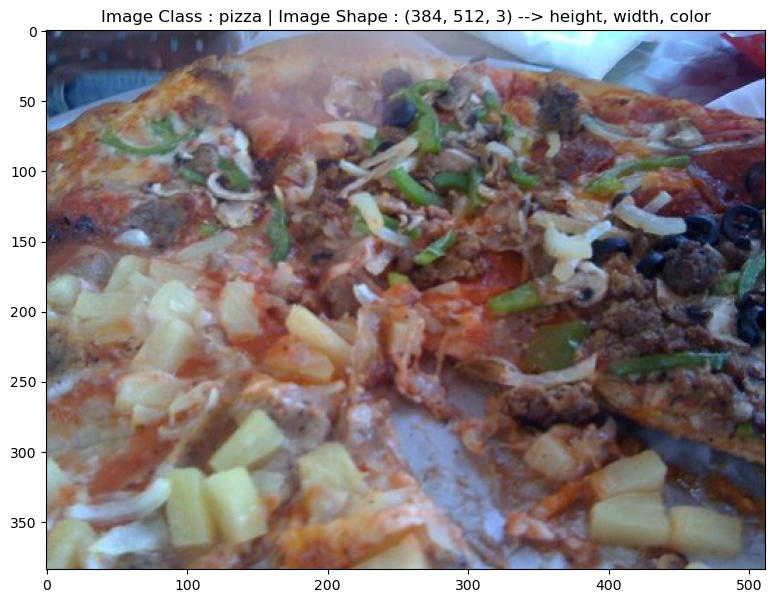

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Trun the image into array
img_as_array = np.asarray(img)

plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"Image Class : {image_class} | Image Shape : {img_as_array.shape} --> height, width, color")

In [21]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [22]:
data_transform = transforms.Compose([
    
    # resize the image from 512x512 to 64x64
    # Custom CNN ----> 64X64
    # 1. Faster training
    # 2. Reduce overfitting 
    # - Larger image contain a lot of details, the model may memorize the tiny pattern instead of learning general feature
    # - Samller image - Force the image to focuse on important structure

    transforms.Resize(size=(64,64)),

    # Flip the image randomly on the horizontal - Data Argumentation 
    # model access to more variations without collecting new data
    # Original ----> flipped
    # Cat facing left ---> Cat facing right
    # It helps the model to see more possibilities

    # Reduce over fitting 
    # - the model may memorize the exact image position 
    # - it become too sensitive to orientation 

    # With flipping 
    # - the model learn general features, not fixed position 

    transforms.RandomHorizontalFlip(p=0.5),

    # Turn image into torch.Tensor
    transforms.ToTensor()
    
    
])

In [23]:
## PIL format, so doesn't show the color, so it is only 2 parameter
img.size

(512, 384)

In [24]:
# Tensor show color, height and width
img_tensor = data_transform(img)
img_tensor.shape

torch.Size([3, 64, 64])

In [25]:
# Since Matplotlib is not working with C,H,W, we need to change as H,W,C
img_tensor = img_tensor.permute(1,2,0)
img_tensor.shape

torch.Size([64, 64, 3])

# Option#1 : Virtualization to compare the PIL image and Tensor image 

Text(0.5, 1.0, 'Tensor Format image')

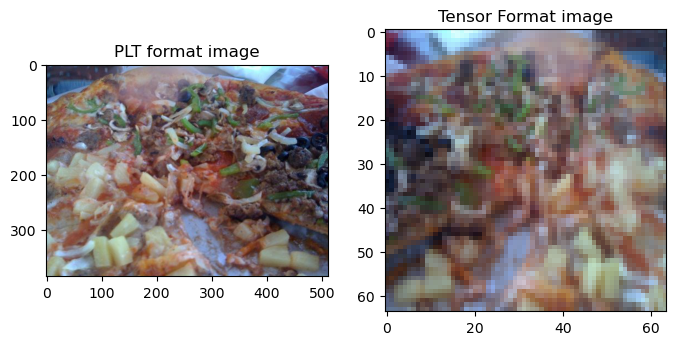

In [27]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("PLT format image")

plt.subplot(1,2,2)
plt.imshow(img_tensor)
plt.title("Tensor Format image")

# Optin#2 : Virtualize the random 5 images to compare 

In [29]:
image_class = image_path.parent.stem

[163, 162, 235, 179, 222]


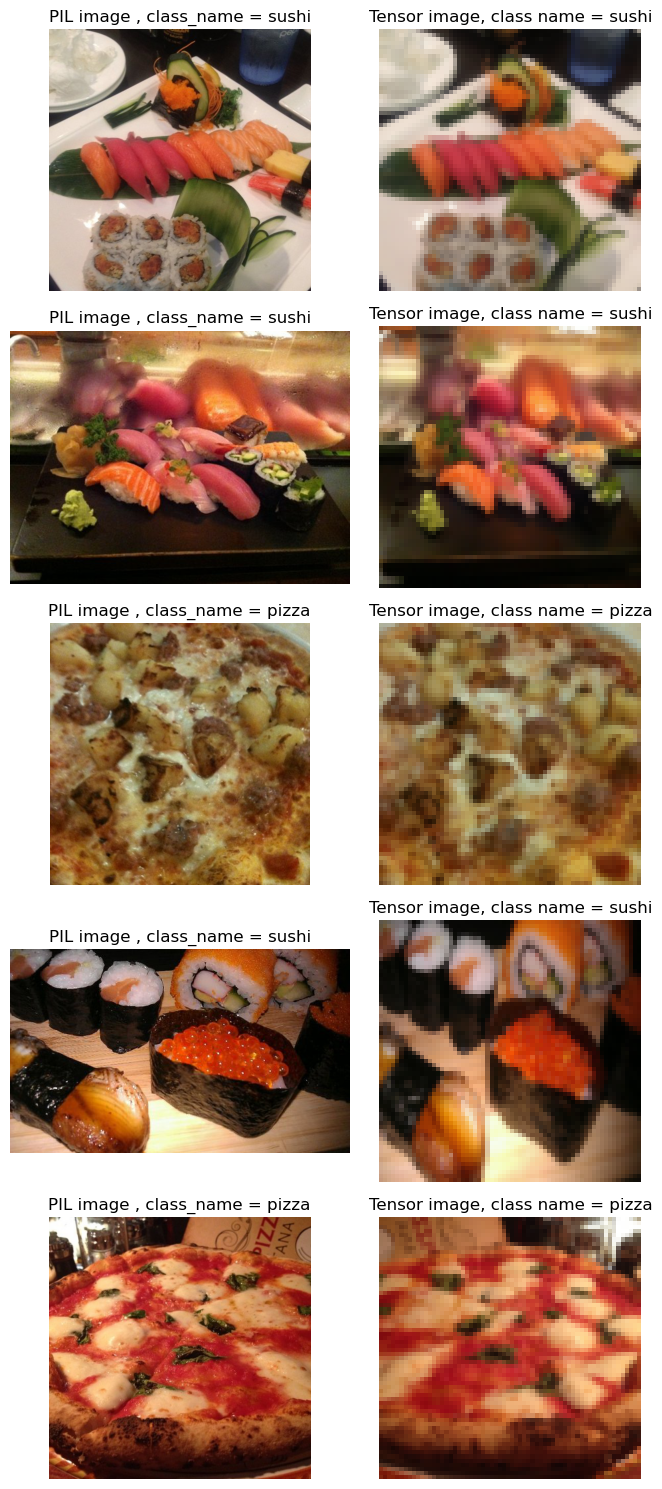

In [30]:
# Pick random 5 index
index = random.sample(range(len(image_path_list)),5)
print(index)

fig, ax = plt.subplots(5,2,figsize=(7,15))

for row, idx in enumerate(index):
    
    PIL_image = Image.open(image_path_list[idx])

    tensor_image = data_transform(PIL_image)
    tensor_image = tensor_image.permute(1,2,0)

    ax[row,0].imshow(PIL_image)
    ax[row,0].set_title(f"PIL image , class_name = {image_path_list[idx].parent.stem}")
    ax[row,0].axis("off")

    ax[row,1].imshow(tensor_image)
    ax[row,1].set_title(f"Tensor image, class name = {image_path_list[idx].parent.stem}")
    ax[row,1].axis("off")
plt.tight_layout()
plt.show()

# Option#3 : Make the function for virtualize the random image to compare the PIL image and tensor image

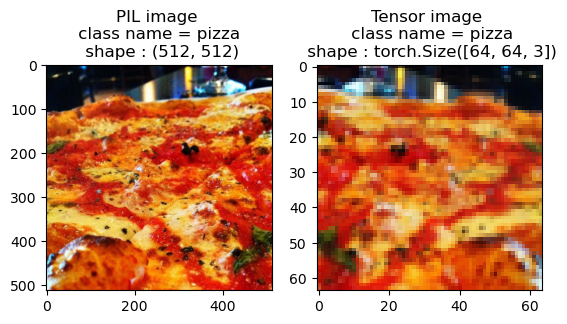

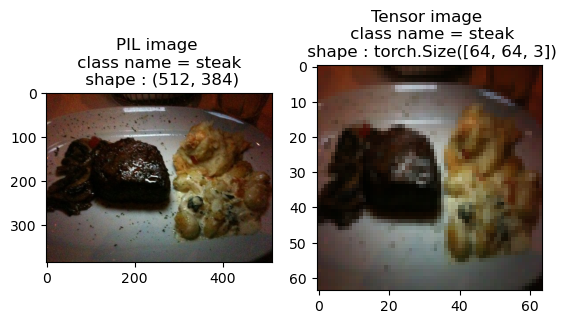

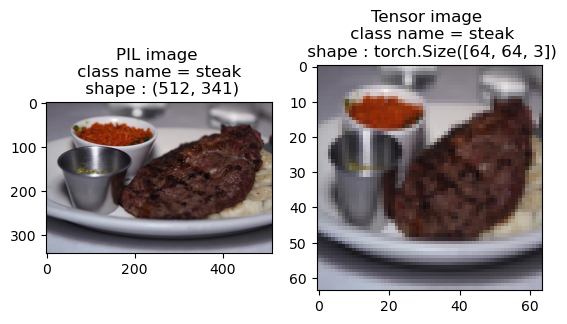

In [32]:
def plot_transformed_image(image_paths, transform, n=3, seed=42):
    random.seed(seed)
    idxes = random.sample(image_paths, k=n)
    for idx in idxes:
        with Image.open(idx) as f:
            fig, ax = plt.subplots(1,2)
            ax[0].imshow(f)
            ax[0].set_title(f"PIL image \n class name = {idx.parent.stem} \n shape : {f.size}")

            tensor_image = transform(f)
            tensor_image = tensor_image.permute(1,2,0)

            ax[1].imshow(tensor_image)
            ax[1].set_title(f"Tensor image \n class name = {idx.parent.stem}\n shape : {tensor_image.shape}")
       

plot_transformed_image(image_path_list, transform=data_transform, n=3)

# Convert the whole dataset into Tensor

In [34]:
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                 transform=data_transform,
                                  target_transform = None
                                 )
test_data = datasets.ImageFolder(root=test_dir,
                                transform=data_transform,
                                 target_transform=None
                                )

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [35]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [36]:
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [37]:
len(train_data), len(test_data)

(225, 75)

In [38]:
img, label = train_data[0][0], train_data[0][1]
print("Image tensor : ", img)
print("Image shape :", img.shape)
print("Image type : ", img.dtype)
print("Label : ", label)

Image tensor :  tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0863],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0706],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0196,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.

Text(0.5, 1.0, 'Tensor image, pizza')

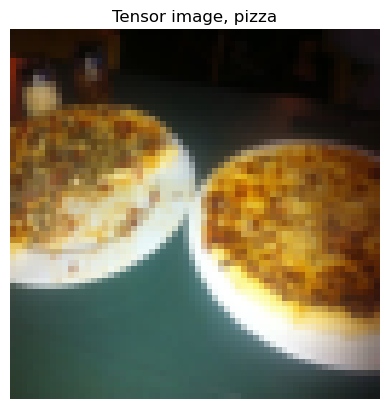

In [39]:
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.title(f"Tensor image, {class_names[label]}")

In [40]:
import os
os.cpu_count()

12

In [41]:
BATCH_SIZE=32
from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset = train_data,
                             batch_size = BATCH_SIZE,
                              num_workers = 1,
                              shuffle = True
                             )
test_dataloader = DataLoader(dataset = test_data,
                            batch_size = BATCH_SIZE,
                             num_workers = 1,
                             shuffle = True
                            )
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x175649f60>,
 <torch.utils.data.dataloader.DataLoader at 0x17564a530>)

In [42]:
len(train_data), len(test_data)

(225, 75)

In [43]:
len(train_dataloader), len(test_dataloader)

(8, 3)

# Loading image deta with a Custom Dataset
- What if a pre-build Dataset creater like `torchvision.datasets.ImageFolder()` doesn't exit, we have to build out own

In [45]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple,Dict,List

In [46]:
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [47]:
# Set up the path for target directory 
target_directory = train_dir

# Get the class name from target directory
class_name_found = sorted([entry.name for entry in list(os.scandir(image_path / "train"))])
print("Class name found : ", class_name_found)

Class name found :  ['pizza', 'steak', 'sushi']


In [48]:
# Create the function for finding the class in target directory
def find_classes(directory : str) -> Tuple[List[str], Dict[str, int]]:
    """
    Find the class folder name in a target directory

    Assumes target directory is in standard image classificaiton format

    Args:
        directory - str : target directory to load classname form

    Returns:
        Tuple[List[str], Dict[str,int]] : List of class name , dict(class_name , index)

    """

    # Get the class name by scanning the target directory 
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

    # Raise the error if class is not found
    if not classes :
        raise FileNotFoundError(f"Couldn't find any class in {directory}, please check fild structure")

    # Create a directory of index labels 
    class_to_idx = {class_name : i for i, class_name in enumerate(classes)}
    return classes, class_to_idx

In [49]:
find_classes(train_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

# Create a custom `Dataset` to replicate `ImageFolder`

In [51]:
from torch.utils.data import Dataset

class ImageFolderCustom(Dataset):

    # Initialize with a target_dir and transform (optional) parameter
    def __init__(self, targ_dir: str, transform=None) -> None:

        #Create class attributes

        # Get all image path
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))

        # Set up transform
        self.transform = transform

        # Create classes and class_to_index attributes
        self.classes, self.class_to_idx = find_classes(targ_dir)

    # Function to load image
    def load_images(self, index:int) -> Image.Image:
        "Open an image via a path and return it"
        image_path = self.paths[index]
        return Image.open(image_path)

    def __len__(self) -> int:
        return len(self.paths)

    # Override the __getitem()__ method
    def __getitem__(self, index: int) -> Tuple[torch.tensor,int]:
        "Return one sample of data , data and label (X,y)"
        img = self.load_images(index)
        class_name = self.paths[index].parent.name
        class_idx = self.class_to_idx[class_name]


        if self.transform:
            return self.transform(img), class_idx
        else:
            return img, class_idx
            

In [52]:
# Create a transform
from torchvision import transforms
train_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
                                
])
test_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5)
])
train_transform, test_transform

(Compose(
     Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
     RandomHorizontalFlip(p=0.5)
     ToTensor()
 ),
 Compose(
     Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
     RandomHorizontalFlip(p=0.5)
 ))

In [53]:
# Use the ImageFolderCustom
train_data_custom = ImageFolderCustom(targ_dir = train_dir,
                                     transform=train_transform
                                     )
test_data_custom = ImageFolderCustom(targ_dir = test_dir,
                                    transform = test_transform
                                    )
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x175648d00>,
 <__main__.ImageFolderCustom at 0x17564b3a0>)

In [54]:
len(train_data_custom), len(test_data_custom)

(225, 75)

In [55]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [56]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

# Compare the reuslt for prebuild ImageFolder and ImageFolderCustom

In [58]:
print(train_data.classes == train_data_custom.classes)
print(train_data.class_to_idx == train_data_custom.class_to_idx)

True
True


# Create a function to display a random image 
1. Take in a `Dataset` and number of other parameters such as `classes` - the name of the target classes, the number of image to display, and random seed
2. To prevent the display getting out of hand, we will cap n at 10 images
3. Set the random seed for reproducible plots
4. Get a list of random sample index
5. Setup the matplotlib
6. Look through the random sample indexes found in step 4 and plot them with matplot
7. Make sure the sample images are the sample of H,W,C

In [60]:
def display_random_image(dataset : torch.utils.data.dataset.Dataset,
                        classes: List[str] = None,
                         n:int = 10,
                         display_shape: bool = True,
                         seed: int = None
                        ):
    #Adjust the display size
    if n > 10:
        n = 10
        print("For just display purpuse, n shouldn't be larger than 10")

    # Set random seed
    if seed:
        random.seed(seed)

    # Get random index
    random_index = random.sample(range(len(dataset)), k=n)

    # Setup plot
    plt.figure(figsize=(16,8))
    for index, sample in enumerate(random_index):
        image,label = dataset[sample][0], dataset[sample][1]
        plt.subplot(1,n,index+1)

        image_adjust = image.permute(1,2,0)
        plt.imshow(image_adjust)
        plt.axis("off")

        plt.title(f"{classes[label]} , {image_adjust.shape}")
        

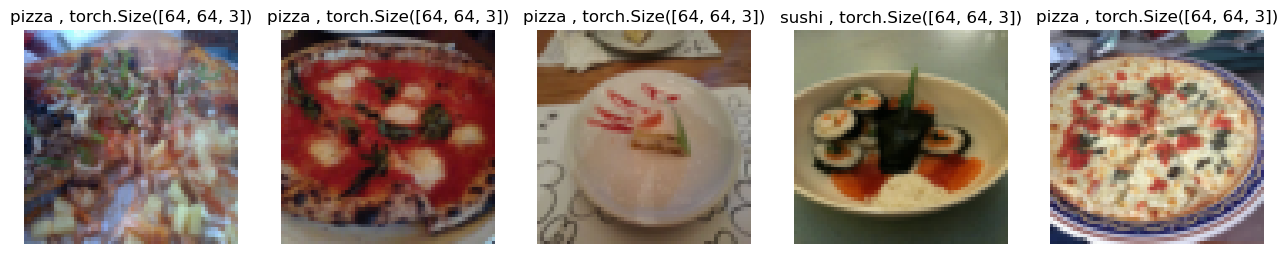

In [61]:
# Check with perbuild ImageFolder "Train Data"
display_random_image(train_data, n=5, classes = class_names, seed=None)

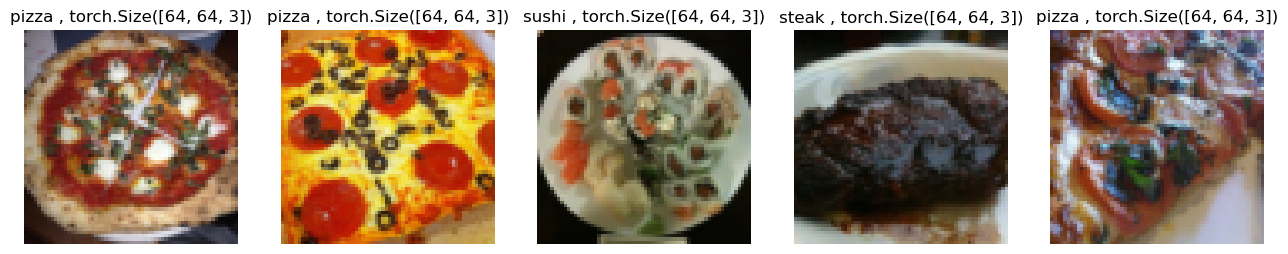

In [62]:
# Check with ImageFolderCustom "Train Data Custom"
display_random_image(train_data_custom, n=5, classes = class_names, seed = None)

# Trun custom loaded image to `DataLoader`

In [64]:
train_dataloader_custom = DataLoader(dataset = train_data_custom,
                                    batch_size = 1,
                                     num_workers = 0,
                                     shuffle = True
                                    )

test_dataloader_custom = DataLoader(dataset = test_data_custom,
                                   batch_size = 1,
                                    num_workers = 0,
                                    shuffle = True
                                   )
train_dataloader_custom, test_dataloader_custom


(<torch.utils.data.dataloader.DataLoader at 0x1761bc340>,
 <torch.utils.data.dataloader.DataLoader at 0x1761bdf90>)

In [68]:
image_custom, label_custom = next(iter(train_dataloader_custom))
print("Image_custom Shape : ", image_custom.shape)
print("Label_custom shape : ", label_custom.shape)

Image_custom Shape :  torch.Size([1, 3, 64, 64])
Label_custom shape :  torch.Size([1])


# Data Argumentation 

In [72]:
from torchvision import transforms
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

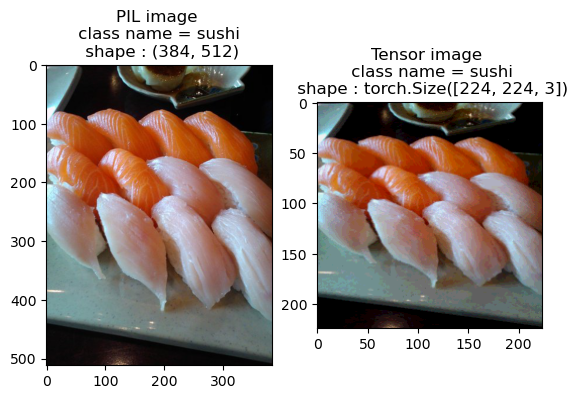

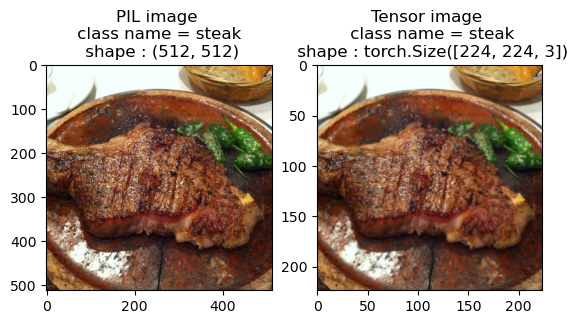

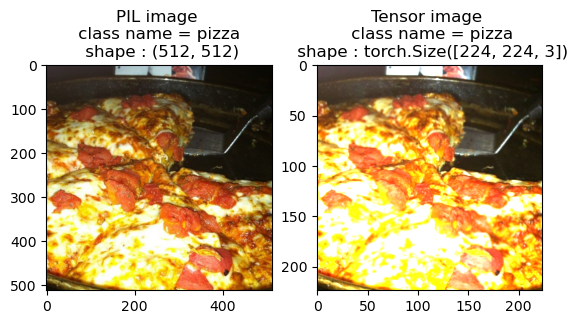

In [74]:
image_path_list = list(image_path.glob("*/*/*.jpg"))

plot_transformed_image(
    image_paths = image_path_list,
    transform = train_transforms,
    n=3,
    seed = None
)

# TinyVGG without Data Argumentation

In [76]:
# Creating the simple transform and load the data for Model0
simple_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])
simple_transform

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)

1. Load the data
2. turning our traing and test data into Dataset with `torchvision.datasets.ImageFolder()`
3. Trun into Dataloader using `torch.utils.data.DataLoader()`

In [85]:
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir, transform=simple_transform)
test_data_simple = datasets.ImageFolder(root=test_dir, transform=simple_transform)

BATCH_SIZE = 32
NUM_WORKERS = 2

train_dataloader_simple = DataLoader(train_data_simple,
                                    batch_size= BATCH_SIZE,
                                     shuffle = True,
                                     num_workers = NUM_WORKERS
                                    )
test_dataloader_simple = DataLoader (test_data_simple, 
                                    batch_size = BATCH_SIZE,
                                     shuffle = False,
                                     num_workers = NUM_WORKERS
                                    )
train_dataloader_simple, test_dataloader_simple

(<torch.utils.data.dataloader.DataLoader at 0x175544070>,
 <torch.utils.data.dataloader.DataLoader at 0x175544610>)

# Creating the TinyVGG for the model

In [88]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape:int, hidden_units:int, output_shape:int) -> None:
        super().__init__()

        # Creating 1st CNN block 
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels = input_shape, 
                     out_channels = hidden_units, 
                      kernel_size = 3,
                      stride = 1, 
                      padding = 0
                     ),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units, 
                     out_channels = hidden_units,
                      kernel_size = 3,
                      stride = 1,
                      padding = 0
                     ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2,
                        stride = 2
                        )
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels = hidden_units, 
                     out_channels = hidden_units, 
                      kernel_size = 3,
                      stride = 1,
                      padding = 0
                     ),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units,
                     out_channels = hidden_units,
                      kernel_size = 3,
                      stride = 1, 
                      padding = 0
                     ),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = hidden_units*13*13,
                     out_features = output_shape
                     )
        )

    def forward (self, x):
        x = self.conv_block1(x)
        # print(x.shape)
        x = self.conv_block2(x)
        # print(x.shape)
        x = self.classifier(x)
        return x

In [103]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape = 3,
                 hidden_units = 10,
                  output_shape = len(train_data.classes)
                 )
model_0

TinyVGG(
  (conv_block1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

## Try a forward pass on a single image - to test the model

In [120]:
# Get a single image 
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape, label_batch.shape

model_0.eval()
image_single, label_single = image_batch[0].unsqueeze(dim=0), label_batch[0]
with torch.inference_mode():
    pred = model_0(image_single)

print("Output : ", pred)
print("Output prediction probability : " , torch.softmax(pred, dim=1))
print("Output prediction label : ", torch.argmax(torch.softmax(pred, dim=1)))
print("Actual label : ", label_single)

Output :  tensor([[ 0.0208, -0.0019,  0.0095]])
Output prediction probability :  tensor([[0.3371, 0.3295, 0.3333]])
Output prediction label :  tensor(0)
Actual label :  tensor(0)


In [121]:
model_0(image_batch)

tensor([[ 2.0789e-02, -1.9350e-03,  9.5317e-03],
        [ 1.8427e-02,  2.4670e-03,  6.6757e-03],
        [ 1.7699e-02,  1.0262e-03,  9.4657e-03],
        [ 2.4441e-02, -3.3526e-03,  9.6011e-03],
        [ 1.9930e-02,  6.6318e-04,  1.0779e-02],
        [ 2.1281e-02,  2.0434e-03,  5.0046e-03],
        [ 2.0999e-02,  1.2869e-04,  1.2473e-02],
        [ 2.1577e-02, -1.9507e-03,  9.6941e-03],
        [ 2.4504e-02, -4.7745e-03,  8.5280e-03],
        [ 2.0252e-02, -4.7293e-04,  1.0908e-02],
        [ 2.2215e-02, -4.1837e-04,  9.8123e-03],
        [ 2.2313e-02, -2.1621e-03,  9.4455e-03],
        [ 2.1841e-02, -3.7132e-03,  8.3782e-03],
        [ 2.2863e-02, -1.7723e-03,  1.0287e-02],
        [ 2.1647e-02, -4.4139e-03,  9.5021e-03],
        [ 2.2096e-02, -4.1425e-03,  9.3853e-03],
        [ 2.1209e-02, -4.4219e-03,  1.1475e-02],
        [ 2.1711e-02, -2.7656e-03,  8.5006e-03],
        [ 1.9951e-02,  2.8294e-05,  8.4380e-03],
        [ 1.8298e-02,  1.6306e-03,  8.5499e-03],
        [ 2.0768e-02

In [124]:
!pip install torchinfo


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [127]:
#use torchinfo to get an idea fo the shapes going through our model
from torchinfo import summary

In [129]:
summary(model_0, input_size=[1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

# Creating the function from Train and Test

In [131]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(), lr=0.01)

In [202]:
def train_step(model: torch.nn.Module,
               dataloader : torch.utils.data.dataloader,
               loss_fn : torch.nn.Module,
               optimizer : torch.optim.Optimizer
              ):
    total_train_loss, total_accurancy = 0, 0
    num_correct = 0
    for batch, (X_train, y_train) in enumerate(dataloader):
        model.eval()
        y_train_pred = model(X_train)

        loss_train = loss_fn(y_train_pred, y_train)

        total_train_loss += loss_train.item()

        optimizer.zero_grad()

        loss_train.backward()

        optimizer.step()

        #Calculate the accurancy 

        #1. Convert raw model output into probabilities
        prob = torch.softmax(y_train_pred, dim=1)
        
        #2. Get the highest probabilities for each sample 
        y_pred_class = torch.argmax(prob, dim=1) 

        #3. get which predictions were correct
        correct_prediction = (y_pred_class == y_train)

        #4. Count how many prediciton are correct
        num_correct = correct_prediction.sum().item()

        #5. Compute accurancy for the current batch 
        batch_accurancy = num_correct/y_train.size(0)

        #6. add the accurancy 
        total_accurancy += batch_accurancy 
    num_correct = 0

        
    total_train_loss /= len(dataloader)
    total_accurancy /= len(dataloader)
    # print("Train Loss : %3f" % total_train_loss, " ---> Accurancy : %3f" % total_accurancy)
    return total_train_loss, total_accurancy

In [220]:
def test_step(model : torch.nn.Module,
             dataloader : torch.utils.data.DataLoader,
              loss_fn : torch.nn.Module,
    
             ):
    model.eval()

    total_test_loss, total_test_accurancy = 0,0
    num_correct = 0

    with torch.inference_mode():

        for batch, (X_test, y_test) in enumerate(dataloader):
            y_test_pred = model(X_test)

            loss_test = loss_fn(y_test_pred, y_test)

            total_test_loss += loss_test.item()
            
            # Calculate the accurancy 
            # 1. Convert raw model into probability 
            prob = torch.softmax(y_test_pred, dim=1)
            
            #2. find the max for each class
            y_pred_class = torch.argmax(prob, dim=1)
            
            #3.get which prediciton are correct
            correct_prediction = (y_pred_class == y_test)
            
            #4. Count how many prediction are correct
            num_correct = correct_prediction.sum().item()
            
            #5. Computer the accurancy for current batch
            batch_accurancy = num_correct / y_test.size(0)
            
            #6. add the accurancy 
            total_test_accurancy += batch_accurancy
        
        num_correct = 0

        total_test_loss /= len(dataloader)
        total_test_accurancy /= len(dataloader)

        # print("Test Loss : %.3f" % total_test_loss, " ----> Test Accurancy : %.3f" % total_test_accurancy)
        
            
        return total_test_loss, total_test_accurancy

In [222]:
# epoches = 5
# for epoch in range(epoches):
#     print("Epoch : ", epoch)
#     train_step(model=model_0,
#              dataloader = train_dataloader_simple,
#               loss_fn = loss_fn,
#               optimizer = optimizer
#              )
#     test_step(model=model_0,
#              dataloader = test_dataloader_simple,
#               loss_fn = loss_fn
#              )

# Combine the train and test step 

In [225]:
# from tqdm import tqdm
def train(model : torch.nn.Module,
         train_dataloader : torch.utils.data.DataLoader,
          test_dataloader : torch.utils.data.DataLoader,
          optimizer : torch.optim.Optimizer,
          loss_fn : torch.nn.Module = nn.CrossEntropyLoss(),
          
          epoches : int = 5
         ):

    # Create empty result dictionary 
    result = {
        "train_loss" : [],
        "train_accurancy" : [],
        "test_loss": [],
        "test_accurancy": []
    }

    #loop through the training and testing for each epoch 
    for epoch in range(epoches):
        train_loss, train_accurancy = train_step(model=model,
                                                dataloader = train_dataloader_simple,
                                                 loss_fn = loss_fn,
                                                 optimizer = optimizer
                                                )
        test_loss, test_accurancy = test_step(model=model,
                                             dataloader = test_dataloader_simple,
                                              loss_fn = loss_fn
                                             )
        print("Epoch : " , epoch)
        print("Train Loss : %.3f" % train_loss , " ---> Train accurancy : %.3f" % train_accurancy)
        print("Test Loss : %3f" % test_loss, " ------> Test accurancy : %.3f" % test_accurancy)

        result["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        result["train_accurancy"].append(train_accurancy.item() if isinstance(train_accurancy, torch.Tensor) else train_accurancy)
        result["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        result["test_accurancy"].append(test_accurancy.item() if isinstance(test_accurancy, torch.Tensor) else test_accurancy)

    return result
        

In [227]:
torch.manual_seed(42)

EPOCHES = 5

model_0 = TinyVGG(input_shape = 3,
                 hidden_units = 10,
                  output_shape = len(train_data.classes)
                 )
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),lr=0.001)

model_0_result = train(model = model_0,
                      train_dataloader = train_dataloader_simple,
                       test_dataloader = test_dataloader_simple,
                       optimizer = optimizer,
                       loss_fn = loss_fn,
                       epoches = EPOCHES
                      )

Epoch :  0
Train Loss : 1.106  ---> Train accurancy : 0.305
Test Loss : 1.098315  ------> Test accurancy : 0.312
Epoch :  1
Train Loss : 1.100  ---> Train accurancy : 0.332
Test Loss : 1.069807  ------> Test accurancy : 0.542
Epoch :  2
Train Loss : 1.086  ---> Train accurancy : 0.492
Test Loss : 1.079912  ------> Test accurancy : 0.523
Epoch :  3
Train Loss : 1.083  ---> Train accurancy : 0.410
Test Loss : 1.059847  ------> Test accurancy : 0.573
Epoch :  4
Train Loss : 1.063  ---> Train accurancy : 0.414
Test Loss : 1.061188  ------> Test accurancy : 0.554


In [228]:
model_0_result

{'train_loss': [1.106342539191246,
  1.0995025485754013,
  1.0862251967191696,
  1.0826152563095093,
  1.0630807429552078],
 'train_accurancy': [0.3046875, 0.33203125, 0.4921875, 0.41015625, 0.4140625],
 'test_loss': [1.0983145634333293,
  1.069806973139445,
  1.0799120267232258,
  1.0598471959431965,
  1.0611876249313354],
 'test_accurancy': [0.31155303030303033,
  0.5416666666666666,
  0.5227272727272728,
  0.5729166666666666,
  0.5539772727272728]}

# Plot the Loss and Accurancy Curve for Model_0

In [237]:
def plot_loss_curve(result: Dict[str, List[float]]):
    # Get the train_loss and train_accurancy of the result dictionary
    train_loss = result["train_loss"]
    train_accurancy = result["train_accurancy"]

    #Get the test_loss and test_accurancy of the result dictionary
    test_loss = result["test_loss"]
    test_accurancy = result["test_accurancy"]

    # Get total epoches 
    epoch = range(len(result["train_loss"]))

    plt.figure(figsize=(15,7))

    # Polt for Train and Test Loss
    plt.subplot(1,2,1)
    plt.plot(epoch, train_loss, label="train_loss") 
    plt.plot(epoch, test_loss, label="test_loss")
    plt.title("Train and Test Loss")
    plt.xlabel("Epoches")
    plt.legend()

    # Plot for Train and Test Accurancy 
    plt.subplot(1,2,2)
    plt.plot(epoch, train_accurancy, label="train_accurancy")
    plt.plot(epoch, test_accurancy, label = "test_accurancy")
    plt.title("Train and Test Accurancy")
    plt.xlabel("Epoches")
    plt.legend()


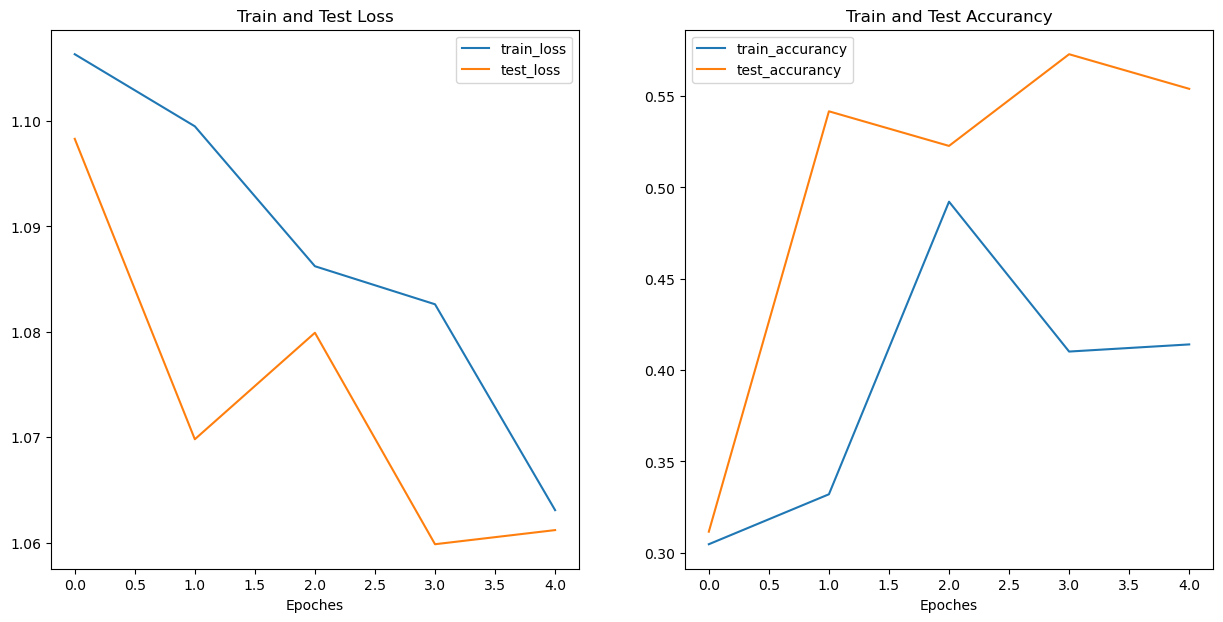

In [239]:
plot_loss_curve(model_0_result)